# 02 — Exploratory Analysis

Inspect document lengths, vocabulary size, and frequent terms before modeling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

df=pd.read_pickle("../data/ag_news_preprocessed.pkl")
print(df.shape)

(120000, 4)


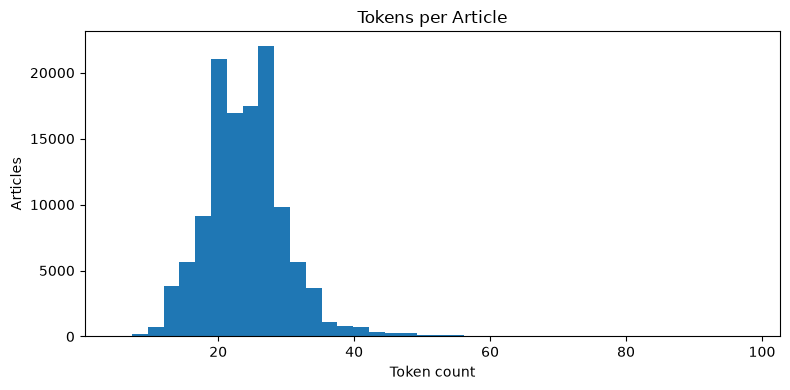

In [2]:
df["token_count"]=df["tokens"].str.len()
plt.figure(figsize=(8,4)); plt.hist(df["token_count"],bins=40)
plt.title("Tokens per Article"); plt.xlabel("Token count"); plt.ylabel("Articles"); plt.tight_layout(); plt.show()

In [3]:
vocabulary=Counter(token for tokens in df["tokens"] for token in tokens)
print("Unique tokens:",len(vocabulary))
vocabulary.most_common(25)

Unique tokens: 89887


[('new', 21223),
 ('said', 19995),
 ('reuters', 17243),
 ('first', 9040),
 ('two', 8925),
 ('world', 7475),
 ('monday', 7448),
 ('wednesday', 7317),
 ('tuesday', 7253),
 ('oil', 7212),
 ('thursday', 7127),
 ('company', 7087),
 ('one', 7051),
 ('friday', 6662),
 ('year', 6595),
 ('inc', 6538),
 ('last', 6315),
 ('york', 6105),
 ('yesterday', 6024),
 ('iraq', 5886),
 ('president', 5804),
 ('million', 5654),
 ('microsoft', 5585),
 ('says', 5339),
 ('game', 5150)]

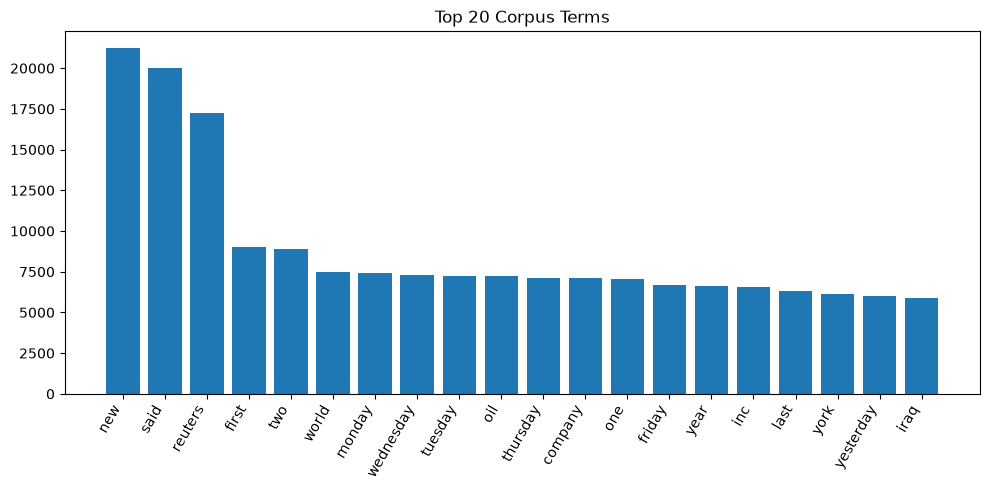

In [4]:
words,counts=zip(*vocabulary.most_common(20))
plt.figure(figsize=(10,5)); plt.bar(words,counts); plt.xticks(rotation=60,ha="right")
plt.title("Top 20 Corpus Terms"); plt.tight_layout(); plt.show()

In [5]:
df.groupby("category")["token_count"].agg(["count","mean","median","max"]).round(2)

,count,mean,median,max
category,,,,
Business,30000,24.44,24.0,89
Sci/Tech,30000,23.77,23.0,98
Sports,30000,23.21,23.0,83
World,30000,24.96,25.0,85
